###Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

###load datasets

In [ ]:
df = pd.read_csv('analysis data.csv')

In [ ]:
df.shape

(7214, 39)

In [ ]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'revenue',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'purchase_year',
 'purchase_month',
 'purchase_quarter',
 'purchase_day',
 'delivery_days',
 'delivery_delay',
 'delivery_status']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       7214 non-null   object        
 1   customer_id                    7214 non-null   object        
 2   order_status                   7214 non-null   object        
 3   order_purchase_timestamp       7214 non-null   datetime64[ns]
 4   order_approved_at              7214 non-null   object        
 5   order_delivered_carrier_date   7214 non-null   object        
 6   order_delivered_customer_date  7214 non-null   object        
 7   order_estimated_delivery_date  7214 non-null   object        
 8   customer_unique_id             7214 non-null   object        
 9   customer_zip_code_prefix       7214 non-null   int64         
 10  customer_city                  7214 non-null   object        
 11  customer_state   

In [ ]:
df.describe()

,order_purchase_timestamp,customer_zip_code_prefix,order_item_id,price,freight_value,revenue,payment_sequential,payment_installments,payment_value,product_name_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay
count,7214,7214.000000,7214.000000,7213.00000,7213.000000,7213.00000,7213.000000,7213.000000,7213.000000,7213.000000,...,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000,7213.000000
mean,2017-12-31 08:13:20.358331136,34908.056695,0.960632,96.87410,16.269836,96.87410,1.067656,2.890891,167.171690,49.177457,...,1830.013725,29.167614,15.775821,22.388465,2017.538888,6.031887,2.352974,15.811452,11.689172,-12.203244
min,2016-09-04 21:15:19,1003.000000,0.000000,0.00000,0.000000,0.00000,1.000000,1.000000,0.000000,10.000000,...,0.000000,7.000000,2.000000,10.000000,2016.000000,1.000000,1.000000,1.000000,0.000000,-62.000000
25%,2017-09-12 18:32:09.500000,11455.500000,1.000000,22.50000,8.590000,22.50000,1.000000,1.000000,60.080000,45.000000,...,350.000000,19.000000,10.000000,15.000000,2017.000000,3.000000,1.000000,8.000000,6.000000,-17.000000
50%,2018-01-19 14:07:12,24115.000000,1.000000,58.67000,15.100000,58.67000,1.000000,2.000000,105.810000,52.000000,...,700.000000,25.000000,13.000000,20.000000,2018.000000,6.000000,2.000000,16.000000,10.000000,-13.000000
75%,2018-05-07 15:34:22,58036.500000,1.000000,115.00000,19.280000,115.00000,1.000000,4.000000,182.400000,56.000000,...,1500.000000,34.000000,19.000000,26.000000,2018.000000,8.000000,3.000000,23.000000,14.000000,-8.000000
max,2018-09-20 13:54:16,99950.000000,7.000000,4059.00000,186.380000,4059.00000,9.000000,24.000000,6726.660000,64.000000,...,30000.000000,105.000000,105.000000,100.000000,2018.000000,12.000000,4.000000,31.000000,143.000000,112.000000
std,NaN,29775.296385,0.662394,170.92862,15.309790,170.92862,0.418808,2.707478,252.151668,9.385271,...,3359.278343,14.714468,12.220749,10.796686,0.505151,3.251790,1.068853,8.696503,8.937116,9.691011


In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

###Recency

In [ ]:
snapshot_date = (
    df['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2018-09-21 13:54:16


In [ ]:
state_recency = (
    df.groupby('customer_state')
      ['order_purchase_timestamp']
      .max()
      .reset_index()
)

state_recency['Recency_Days'] = (
    snapshot_date
    - state_recency['order_purchase_timestamp']
).dt.days

state_recency.head()

,customer_state,order_purchase_timestamp,Recency_Days
0,AC,2018-04-26 12:47:48,148
1,AL,2018-08-11 16:13:27,40
2,AM,2018-07-04 03:04:34,79
3,AP,2018-03-13 19:06:38,191
4,BA,2018-08-21 10:19:27,31


In [ ]:
state_recency['Recency_Level'] = pd.qcut(
    state_recency['Recency_Days'],
    q=3,
    labels=[
        'High Recency',
        'Medium Recency',
        'Low Recency'
    ]
)

In [ ]:
state_recency.sort_values(
    'Recency_Days'
)

,customer_state,order_purchase_timestamp,Recency_Days,Recency_Level
10,MG,2018-09-20 13:54:16,1,High Recency
23,SC,2018-09-13 09:56:12,8,High Recency
25,SP,2018-08-29 16:27:49,22,High Recency
22,RS,2018-08-28 14:01:04,23,High Recency
5,CE,2018-08-28 08:18:22,24,High Recency
18,RJ,2018-08-25 22:17:18,26,High Recency
14,PB,2018-08-23 13:48:07,29,High Recency
6,DF,2018-08-23 00:53:00,29,High Recency
8,GO,2018-08-22 00:07:15,30,High Recency
17,PR,2018-08-21 18:42:15,30,High Recency


###Top 10 States by Recency

In [ ]:
top10_recency_states = (
    state_recency
    .sort_values(
        'Recency_Days'
    )
    .head(10)
)

top10_recency_states

,customer_state,order_purchase_timestamp,Recency_Days,Recency_Level
10,MG,2018-09-20 13:54:16,1,High Recency
23,SC,2018-09-13 09:56:12,8,High Recency
25,SP,2018-08-29 16:27:49,22,High Recency
22,RS,2018-08-28 14:01:04,23,High Recency
5,CE,2018-08-28 08:18:22,24,High Recency
18,RJ,2018-08-25 22:17:18,26,High Recency
14,PB,2018-08-23 13:48:07,29,High Recency
6,DF,2018-08-23 00:53:00,29,High Recency
8,GO,2018-08-22 00:07:15,30,High Recency
17,PR,2018-08-21 18:42:15,30,High Recency


###Heatmap for Recency

/tmp/ipykernel_2817/1109290361.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


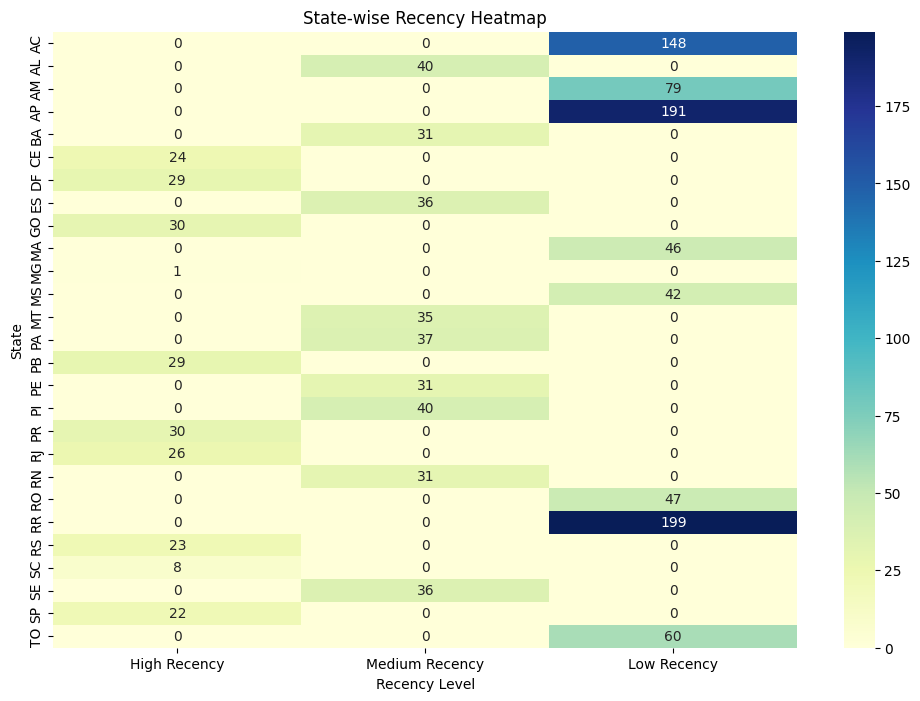

In [ ]:
heatmap_data = pd.pivot_table(
    state_recency,
    values='Recency_Days',
    index='customer_state',
    columns='Recency_Level',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'State-wise Recency Heatmap'
)

plt.xlabel('Recency Level')
plt.ylabel('State')

plt.show()

###Bar Chart for Top 10 States Recency


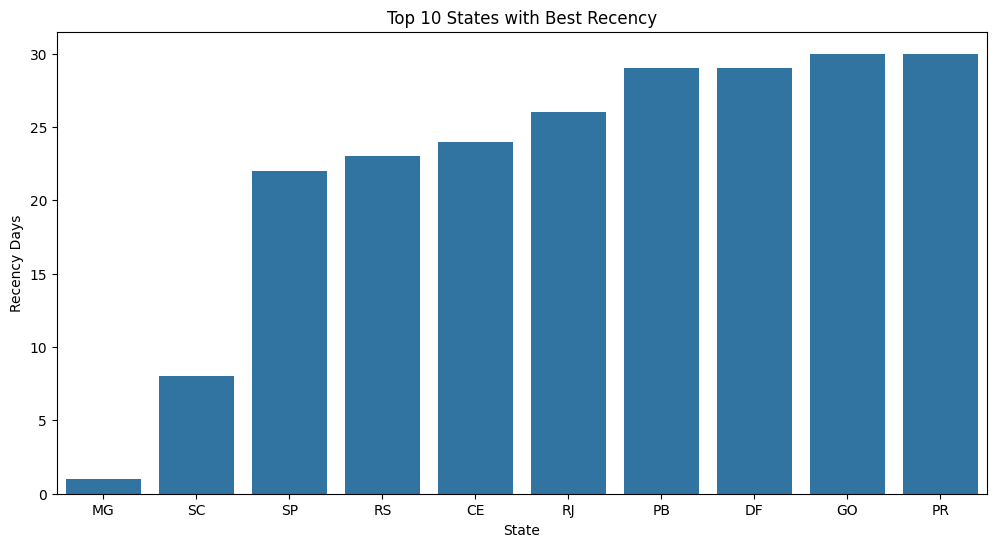

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_recency_states,
    x='customer_state',
    y='Recency_Days'
)

plt.title(
    'Top 10 States with Best Recency'
)

plt.xlabel('State')
plt.ylabel('Recency Days')

plt.show()

In [ ]:
bottom10_recency_states = (
    state_recency
    .sort_values(
        'Recency_Days',
        ascending=False
    )
    .head(10)
)

bottom10_recency_states

,customer_state,order_purchase_timestamp,Recency_Days,Recency_Level
21,RR,2018-03-06 09:30:25,199,Low Recency
3,AP,2018-03-13 19:06:38,191,Low Recency
0,AC,2018-04-26 12:47:48,148,Low Recency
2,AM,2018-07-04 03:04:34,79,Low Recency
26,TO,2018-07-23 10:21:28,60,Low Recency
20,RO,2018-08-04 17:00:12,47,Low Recency
9,MA,2018-08-05 14:47:24,46,Low Recency
11,MS,2018-08-10 12:43:39,42,Low Recency
1,AL,2018-08-11 16:13:27,40,Medium Recency
16,PI,2018-08-11 16:52:23,40,Medium Recency


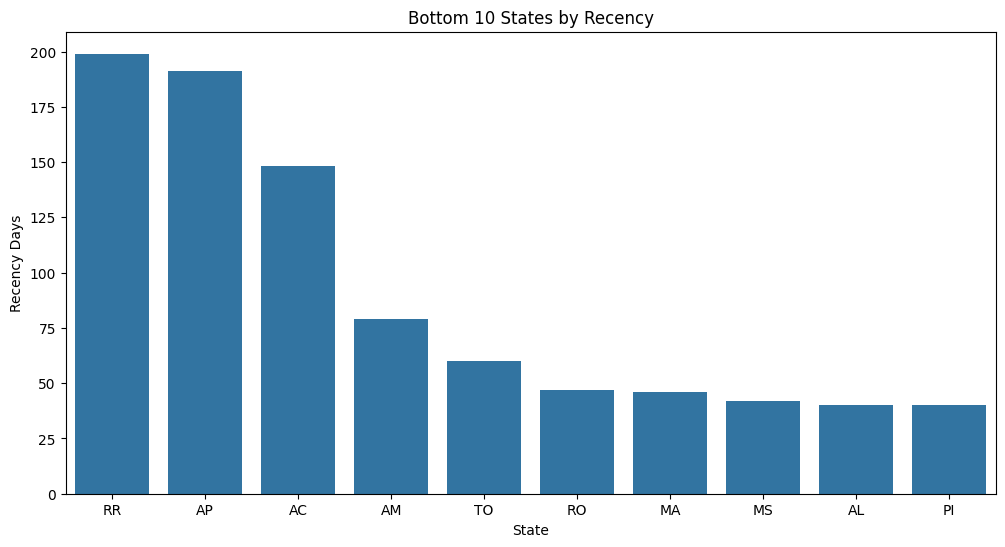

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10_recency_states,
    x='customer_state',
    y='Recency_Days'
)

plt.title(
    'Bottom 10 States by Recency'
)

plt.xlabel('State')
plt.ylabel('Recency Days')

plt.show()

###Frequency

**Calculate State-wise Frequency**

In [ ]:
state_frequency = (
    df.groupby('customer_state')
      ['order_id']
      .nunique()
      .reset_index()
)

state_frequency.columns = [
    'State',
    'Frequency'
]

state_frequency.head()

,State,Frequency
0,AC,8
1,AL,33
2,AM,3
3,AP,2
4,BA,216


**Create Frequency Levels**

In [ ]:
state_frequency['Frequency_Level'] = pd.qcut(
    state_frequency['Frequency'],
    q=3,
    labels=[
        'Low Frequency',
        'Medium Frequency',
        'High Frequency'
    ]
)

**View State Classification**

In [ ]:
state_frequency.sort_values(
    'Frequency',
    ascending=False
)

,State,Frequency,Frequency_Level
25,SP,2670,High Frequency
18,RJ,813,High Frequency
10,MG,700,High Frequency
22,RS,343,High Frequency
17,PR,323,High Frequency
23,SC,228,High Frequency
4,BA,216,High Frequency
8,GO,135,High Frequency
6,DF,134,High Frequency
7,ES,130,Medium Frequency


**Top 10 States by Frequency**

In [ ]:
top10_frequency_states = (
    state_frequency
    .sort_values(
        'Frequency',
        ascending=False
    )
    .head(10)
)

top10_frequency_states

,State,Frequency,Frequency_Level
25,SP,2670,High Frequency
18,RJ,813,High Frequency
10,MG,700,High Frequency
22,RS,343,High Frequency
17,PR,323,High Frequency
23,SC,228,High Frequency
4,BA,216,High Frequency
8,GO,135,High Frequency
6,DF,134,High Frequency
7,ES,130,Medium Frequency


**Bottom 10 States by Frequency**

In [ ]:
bottom10_frequency_states = (
    state_frequency
    .sort_values(
        'Frequency'
    )
    .head(10)
)

bottom10_frequency_states

,State,Frequency,Frequency_Level
3,AP,2,Low Frequency
2,AM,3,Low Frequency
21,RR,3,Low Frequency
0,AC,8,Low Frequency
20,RO,11,Low Frequency
26,TO,19,Low Frequency
19,RN,29,Low Frequency
14,PB,31,Low Frequency
24,SE,31,Low Frequency
1,AL,33,Medium Frequency


**Frequency Heatmap**

/tmp/ipykernel_2817/1298359322.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


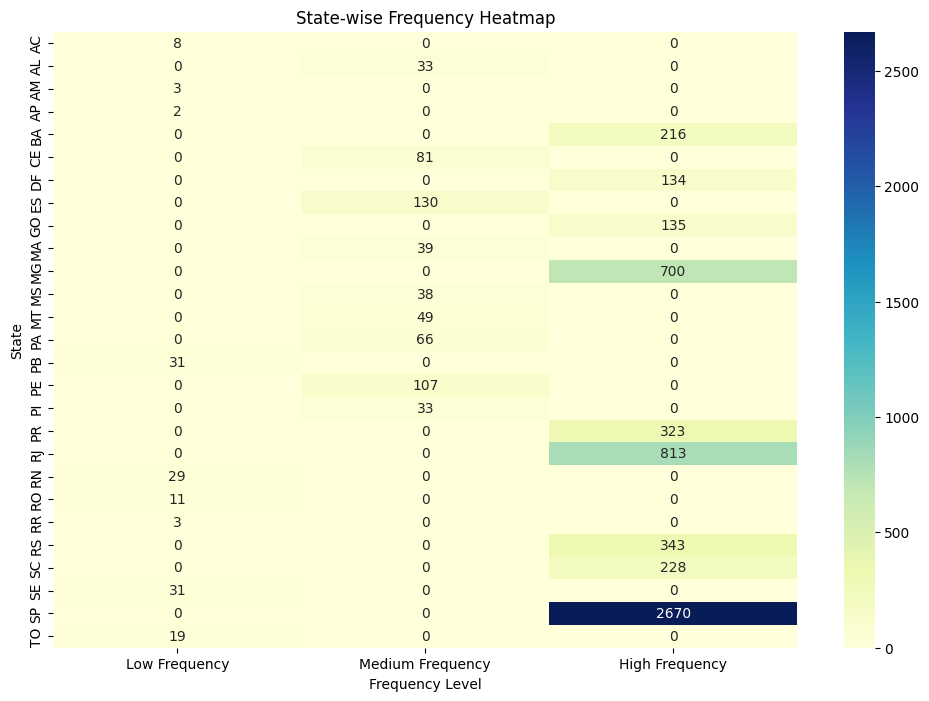

In [ ]:
heatmap_data = pd.pivot_table(
    state_frequency,
    values='Frequency',
    index='State',
    columns='Frequency_Level',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'State-wise Frequency Heatmap'
)

plt.xlabel('Frequency Level')
plt.ylabel('State')

plt.show()

**Top 10 Frequency States Graph**

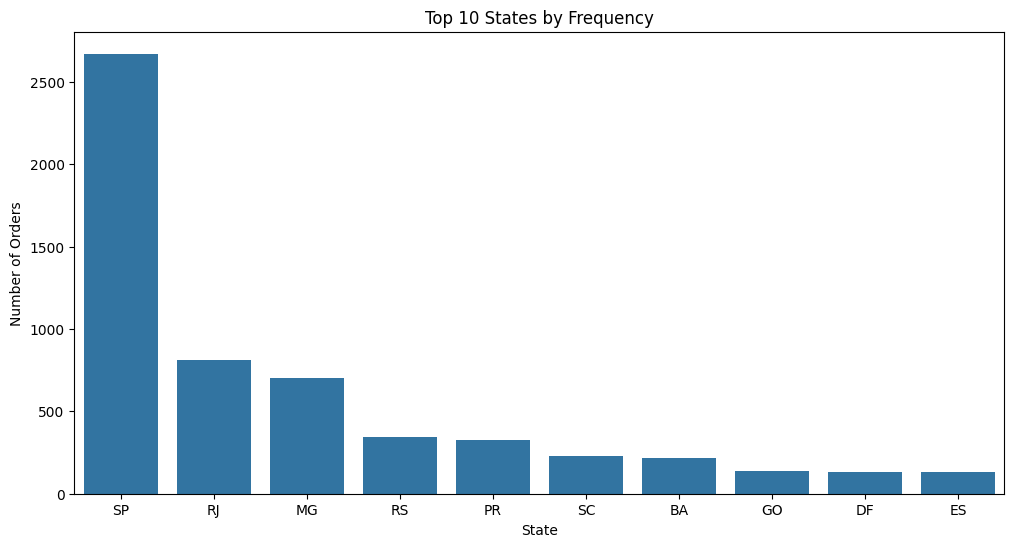

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_frequency_states,
    x='State',
    y='Frequency'
)

plt.title(
    'Top 10 States by Frequency'
)

plt.xlabel('State')
plt.ylabel('Number of Orders')

plt.show()

**Bottom 10 Frequency States Graph**

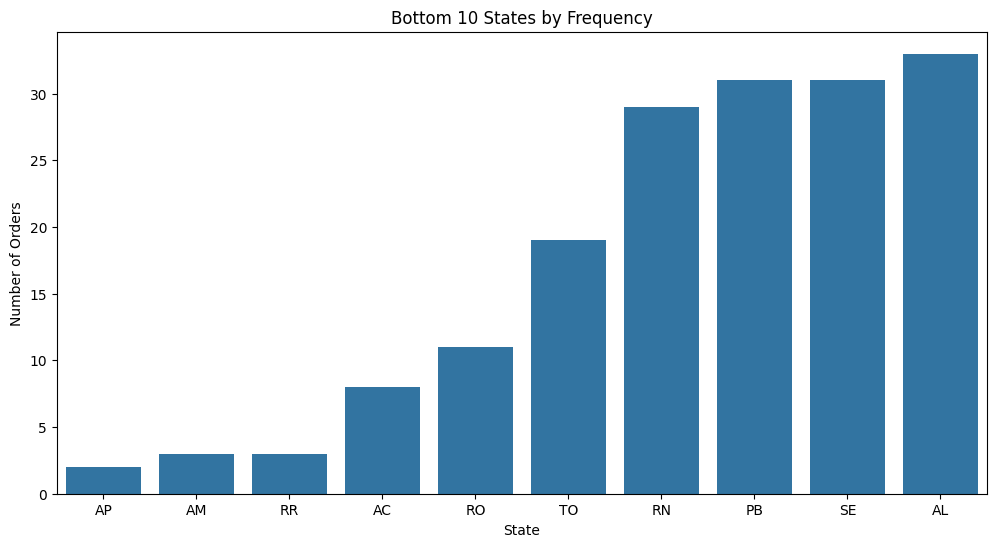

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10_frequency_states,
    x='State',
    y='Frequency'
)

plt.title(
    'Bottom 10 States by Frequency'
)

plt.xlabel('State')
plt.ylabel('Number of Orders')

plt.show()

**Calculate State-wise Monetary Value**

In [ ]:
state_monetary = (
    df.groupby('customer_state')
      ['revenue']
      .sum()
      .reset_index()
)

state_monetary.columns = [
    'State',
    'Monetary'
]

state_monetary.head()

,State,Monetary
0,AC,1246.87
1,AL,4180.69
2,AM,399.29
3,AP,214.89
4,BA,24285.88


**Create Monetary Levels**

In [ ]:
state_monetary['Monetary_Level'] = pd.qcut(
    state_monetary['Monetary'],
    q=3,
    labels=[
        'Low Monetary',
        'Medium Monetary',
        'High Monetary'
    ]
)

**View State Classification**

In [ ]:
state_monetary.sort_values(
    'Monetary',
    ascending=False
)

,State,Monetary,Monetary_Level
25,SP,263937.57,High Monetary
18,RJ,105488.12,High Monetary
10,MG,73850.15,High Monetary
17,PR,38535.63,High Monetary
22,RS,36799.75,High Monetary
23,SC,28578.24,High Monetary
4,BA,24285.88,High Monetary
8,GO,19105.83,High Monetary
6,DF,14422.97,High Monetary
5,CE,13813.25,Medium Monetary


**Top 10 States by Monetary**

In [ ]:
top10_monetary_states = (
    state_monetary
    .sort_values(
        'Monetary',
        ascending=False
    )
    .head(10)
)

top10_monetary_states

,State,Monetary,Monetary_Level
25,SP,263937.57,High Monetary
18,RJ,105488.12,High Monetary
10,MG,73850.15,High Monetary
17,PR,38535.63,High Monetary
22,RS,36799.75,High Monetary
23,SC,28578.24,High Monetary
4,BA,24285.88,High Monetary
8,GO,19105.83,High Monetary
6,DF,14422.97,High Monetary
5,CE,13813.25,Medium Monetary


**Bottom 10 States by Monetary**

In [ ]:
bottom10_monetary_states = (
    state_monetary
    .sort_values(
        'Monetary'
    )
    .head(10)
)

bottom10_monetary_states

,State,Monetary,Monetary_Level
21,RR,195.88,Low Monetary
3,AP,214.89,Low Monetary
2,AM,399.29,Low Monetary
0,AC,1246.87,Low Monetary
20,RO,1287.79,Low Monetary
26,TO,2120.37,Low Monetary
14,PB,2787.16,Low Monetary
11,MS,3992.72,Low Monetary
19,RN,4018.95,Low Monetary
1,AL,4180.69,Medium Monetary


**Monetary Heatmap**

/tmp/ipykernel_2817/3927002424.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


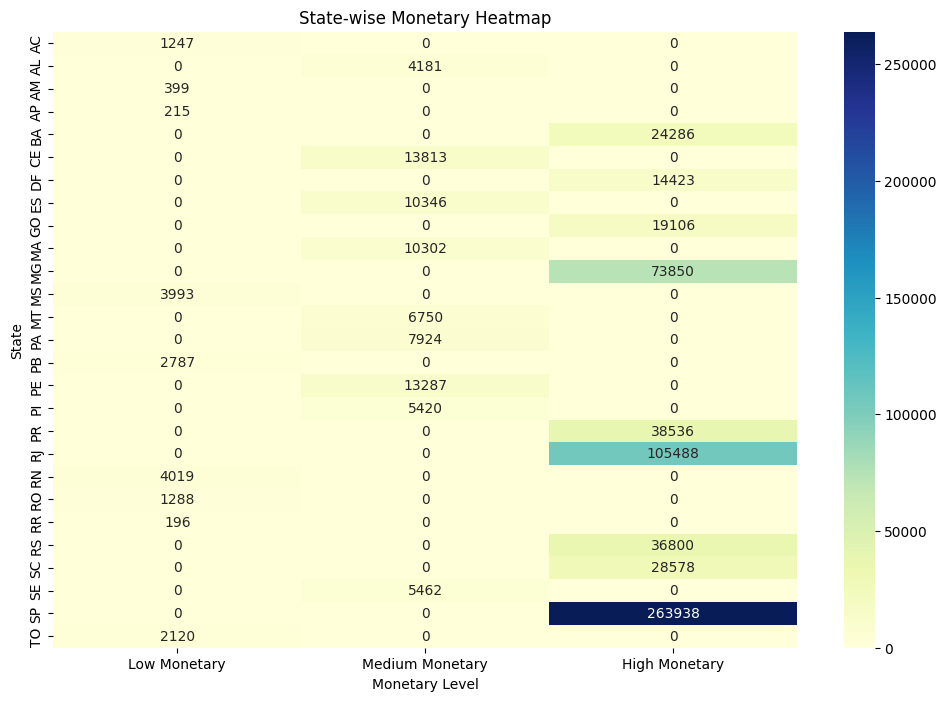

In [ ]:
heatmap_data = pd.pivot_table(
    state_monetary,
    values='Monetary',
    index='State',
    columns='Monetary_Level',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'State-wise Monetary Heatmap'
)

plt.xlabel('Monetary Level')
plt.ylabel('State')

plt.show()

**Top 10 Monetary States Graph**

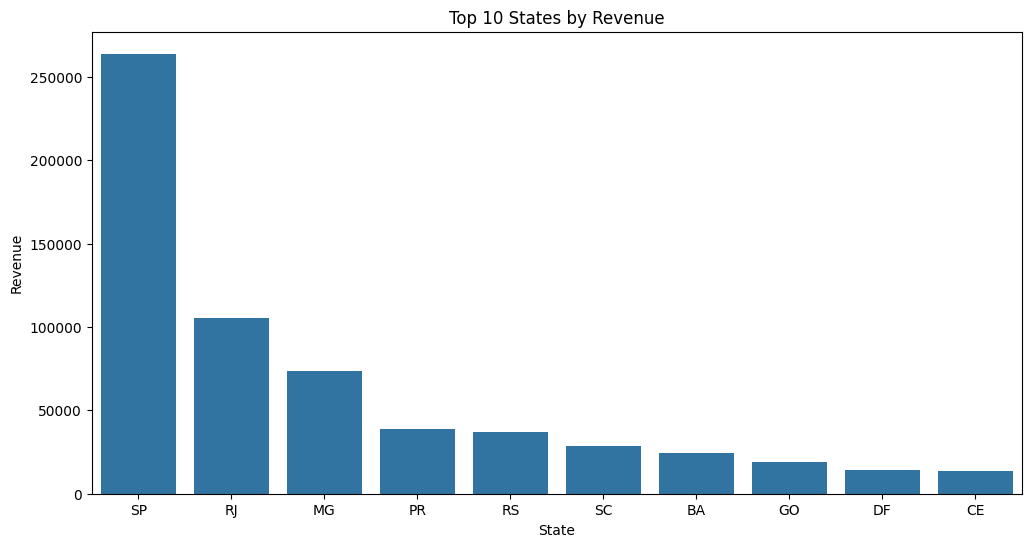

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_monetary_states,
    x='State',
    y='Monetary'
)

plt.title(
    'Top 10 States by Revenue'
)

plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

**Bottom 10 Monetary States Graph**

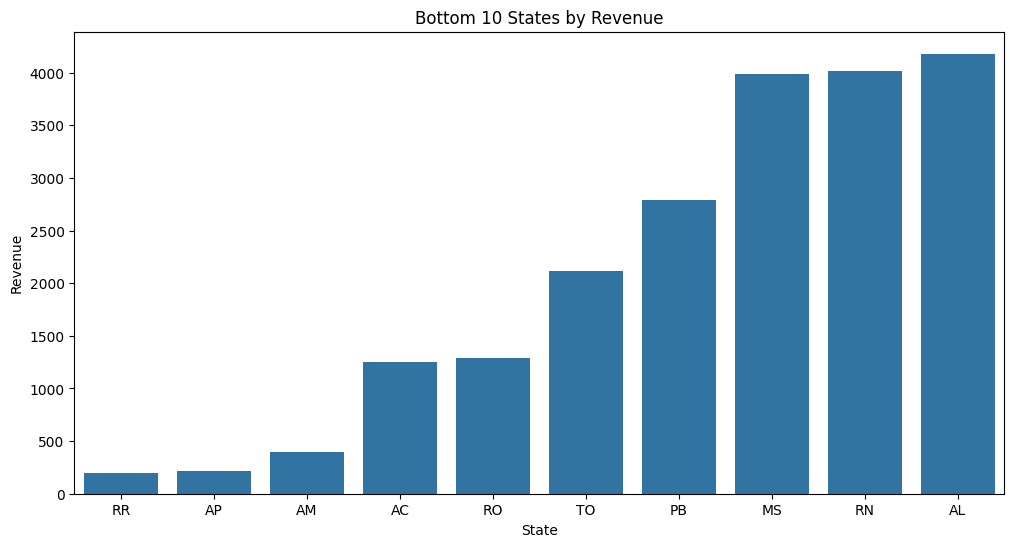

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10_monetary_states,
    x='State',
    y='Monetary'
)

plt.title(
    'Bottom 10 States by Revenue'
)

plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

**State-Level RFM Summary**

In [ ]:
state_rfm = (
    state_recency[['customer_state','Recency_Days']]
    .merge(
        state_frequency[['State','Frequency']],
        left_on='customer_state',
        right_on='State'
    )
    .merge(
        state_monetary[['State','Monetary']],
        on='State'
    )
)

state_rfm.head()

,customer_state,Recency_Days,State,Frequency,Monetary
0,AC,148,AC,8,1246.87
1,AL,40,AL,33,4180.69
2,AM,79,AM,3,399.29
3,AP,191,AP,2,214.89
4,BA,31,BA,216,24285.88


In [ ]:
# Top 10 Recency States (lowest recency days = best)
top10_recency = (
    state_recency
    .sort_values('Recency_Days')
    .head(10)
    [['customer_state', 'Recency_Days']]
)

top10_recency.columns = [
    'Top_Recency_State',
    'Recency_Days'
]

# Top 10 Frequency States
top10_frequency = (
    state_frequency
    .sort_values('Frequency', ascending=False)
    .head(10)
    [['State', 'Frequency']]
)

top10_frequency.columns = [
    'Top_Frequency_State',
    'Frequency'
]

# Top 10 Monetary States
top10_monetary = (
    state_monetary
    .sort_values('Monetary', ascending=False)
    .head(10)
    [['State', 'Monetary']]
)

top10_monetary.columns = [
    'Top_Monetary_State',
    'Monetary'
]

# Combine into one table
top10_rfm_states = pd.concat(
    [
        top10_recency.reset_index(drop=True),
        top10_frequency.reset_index(drop=True),
        top10_monetary.reset_index(drop=True)
    ],
    axis=1
)

print(top10_rfm_states)

  Top_Recency_State  Recency_Days Top_Frequency_State  Frequency  \
0                MG             1                  SP       2670   
1                SC             8                  RJ        813   
2                SP            22                  MG        700   
3                RS            23                  RS        343   
4                CE            24                  PR        323   
5                RJ            26                  SC        228   
6                PB            29                  BA        216   
7                DF            29                  GO        135   
8                GO            30                  DF        134   
9                PR            30                  ES        130   

  Top_Monetary_State   Monetary  
0                 SP  263937.57  
1                 RJ  105488.12  
2                 MG   73850.15  
3                 PR   38535.63  
4                 RS   36799.75  
5                 SC   28578.24  
6            

**Customer Recency**

In [ ]:
snapshot_date = (
    df['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

customer_recency = (
    df.groupby('customer_unique_id')
      ['order_purchase_timestamp']
      .max()
      .reset_index()
)

customer_recency['Recency_Days'] = (
    snapshot_date -
    customer_recency['order_purchase_timestamp']
).dt.days

**Top 10 Customers by Recency**

In [ ]:
top10_recency_customers = (
    customer_recency
    .sort_values('Recency_Days')
    .head(10)
)

top10_recency_customers

,customer_unique_id,order_purchase_timestamp,Recency_Days
207,08642cd329066fe11ec63293f714f2f8,2018-09-20 13:54:16,1
4727,c1ee153508c6b785b491443a95ff364e,2018-09-13 09:56:12,8
4112,a8dd81392e5eee5d979c629a76abec2a,2018-08-29 16:27:49,22
4667,bfd827e8a21c8be7bdef29573a885b76,2018-08-28 14:01:04,23
5970,f3e71989aaa365356d121d87129aa2ce,2018-08-28 14:32:59,23
1919,4fa4365000c7090fcb8cad5713c6d3db,2018-08-28 15:26:39,23
824,21dbe8eabd00b34492a939c540e2b1a7,2018-08-29 10:22:35,23
4063,a712a430955027da5bc257a10073a390,2018-08-28 21:56:30,23
4772,c4053ab276391fff6ac7736873cfc950,2018-08-27 19:39:33,24
5383,dc4b0942fb780633d44f4f73ff69dd92,2018-08-27 18:50:06,24


**Customer Frequency**

In [ ]:
customer_frequency = (
    df.groupby('customer_unique_id')
      ['order_id']
      .nunique()
      .reset_index()
)

customer_frequency.columns = [
    'CustomerID',
    'Frequency'
]

**Top 10 Customers by Frequency**

In [ ]:
top10_frequency_customers = (
    customer_frequency
    .sort_values(
        'Frequency',
        ascending=False
    )
    .head(10)
)

top10_frequency_customers

,CustomerID,Frequency
3393,8d50f5eadf50201ccdcedfb9e2ac8455,3
2133,58aa424ba24df5dc745e1a3941abc5a3,2
3016,7e30d2336a1f1182766cf6fb863d5554,2
452,12f5d6e1cbf93dafd9dcc19095df0b3d,2
4801,c5400d2fca348bd1313426efe4b10a51,2
1718,47c89a36acb8a73127ec91d0542289b5,2
4732,c2551ea089b7ebbc67a2ea8757152514,2
3796,9cc5a07f169a1606fd347a56683e6ea6,2
2908,7a380cb5434e6b6b5b37d45bb99dbe8a,2
92,041caba6a63ace5818387698ea85cdb2,2


**Customer Monetary**

In [ ]:
customer_monetary = (
    df.groupby('customer_unique_id')
      ['revenue']
      .sum()
      .reset_index()
)

customer_monetary.columns = [
    'CustomerID',
    'Monetary'
]

**Top 10 Customers by Revenue**

In [ ]:
top10_monetary_customers = (
    customer_monetary
    .sort_values(
        'Monetary',
        ascending=False
    )
    .head(10)
)

top10_monetary_customers

,CustomerID,Monetary
4932,ca27f3dac28fb1063faddd424c9d95fa,4059.00
3751,9b11e010850a4045d2da80c7783fdbd1,3198.00
4564,bbeb907759ef5fc169099af3c88d535d,3105.00
662,1b76903617af13189607a36b0469f6f3,3099.75
3292,895617ab63a9ad8881d9470f7427cd25,2999.99
2335,6172bd5b7f52ade8c6c4548b448ff54f,2999.89
953,287a7cdacbcda8f842d7719e77cb8457,2150.00
627,1a3a962a15f8c6ee0178e1102387d3cc,2139.99
451,12ebfdb41392890f9d7a8de957274741,2110.00
70,02e8a66528e84b3ca6150d9b1e03a26f,2110.00


In [ ]:
top10_recency = (
    top10_recency_customers[
        ['customer_unique_id',
         'Recency_Days']
    ]
    .reset_index(drop=True)
)

top10_frequency = (
    top10_frequency_customers[
        ['CustomerID',
         'Frequency']
    ]
    .reset_index(drop=True)
)

top10_monetary = (
    top10_monetary_customers[
        ['CustomerID',
         'Monetary']
    ]
    .reset_index(drop=True)
)

top10_customer_rfm = pd.concat(
    [
        top10_recency,
        top10_frequency,
        top10_monetary
    ],
    axis=1
)

top10_customer_rfm

,customer_unique_id,Recency_Days,CustomerID,Frequency,CustomerID,Monetary
0,08642cd329066fe11ec63293f714f2f8,1,8d50f5eadf50201ccdcedfb9e2ac8455,3,ca27f3dac28fb1063faddd424c9d95fa,4059.00
1,c1ee153508c6b785b491443a95ff364e,8,58aa424ba24df5dc745e1a3941abc5a3,2,9b11e010850a4045d2da80c7783fdbd1,3198.00
2,a8dd81392e5eee5d979c629a76abec2a,22,7e30d2336a1f1182766cf6fb863d5554,2,bbeb907759ef5fc169099af3c88d535d,3105.00
3,bfd827e8a21c8be7bdef29573a885b76,23,12f5d6e1cbf93dafd9dcc19095df0b3d,2,1b76903617af13189607a36b0469f6f3,3099.75
4,f3e71989aaa365356d121d87129aa2ce,23,c5400d2fca348bd1313426efe4b10a51,2,895617ab63a9ad8881d9470f7427cd25,2999.99
5,4fa4365000c7090fcb8cad5713c6d3db,23,47c89a36acb8a73127ec91d0542289b5,2,6172bd5b7f52ade8c6c4548b448ff54f,2999.89
6,21dbe8eabd00b34492a939c540e2b1a7,23,c2551ea089b7ebbc67a2ea8757152514,2,287a7cdacbcda8f842d7719e77cb8457,2150.00
7,a712a430955027da5bc257a10073a390,23,9cc5a07f169a1606fd347a56683e6ea6,2,1a3a962a15f8c6ee0178e1102387d3cc,2139.99
8,c4053ab276391fff6ac7736873cfc950,24,7a380cb5434e6b6b5b37d45bb99dbe8a,2,12ebfdb41392890f9d7a8de957274741,2110.00
9,dc4b0942fb780633d44f4f73ff69dd92,24,041caba6a63ace5818387698ea85cdb2,2,02e8a66528e84b3ca6150d9b1e03a26f,2110.00


**Create RFM Table**

In [ ]:
rfm = (
    df.groupby('customer_unique_id')
    .agg({
        'order_purchase_timestamp': lambda x: (
            snapshot_date - x.max()
        ).days,
        'order_id': 'nunique',
        'revenue': 'sum'
    })
    .reset_index()
)

rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,00082cbe03e478190aadbea78542e933,305,1,79.00
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00


**Assign R Score**

In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

**Assign F Score**

In [ ]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

**Assign M Score**

In [ ]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

**Create RFM Score**

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,00082cbe03e478190aadbea78542e933,305,1,79.00,2,1,3,213
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90,1,1,3,113
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99,4,1,5,415
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00,4,1,1,411
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00,5,1,2,512


**Segment Summary**

In [ ]:
def segment_customer(row):
    # Convert scores to integers for comparison
    r_score = int(row['R_Score'])
    f_score = int(row['F_Score'])
    m_score = int(row['M_Score'])

    if r_score >= 4 and f_score >= 4 and m_score >= 4:
        return 'Champions'
    elif r_score >= 3 and f_score >= 4:
        return 'Loyal Customers'
    elif r_score >= 4 and f_score >= 2:
        return 'Potential Loyalists'
    elif r_score <= 2 and f_score >= 3:
        return 'At Risk'
    elif r_score <= 2 and f_score <= 2 and m_score <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID','count'),
        Avg_Recency=('Recency','mean'),
        Avg_Frequency=('Frequency','mean'),
        Avg_Monetary=('Monetary','mean')
    )
    .sort_values(
        'Customers',
        ascending=False
    )
)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Need Attention,1870,266.327273,1.000000,130.957144
At Risk,1492,420.798257,1.002681,107.259149
Loyal Customers,1098,170.438069,1.002732,62.128898
Potential Loyalists,981,113.960245,1.000000,111.249562
Champions,429,113.650350,1.011655,257.800490
Lost Customers,393,424.106870,1.000000,14.968473


**Segment Distribution Chart**

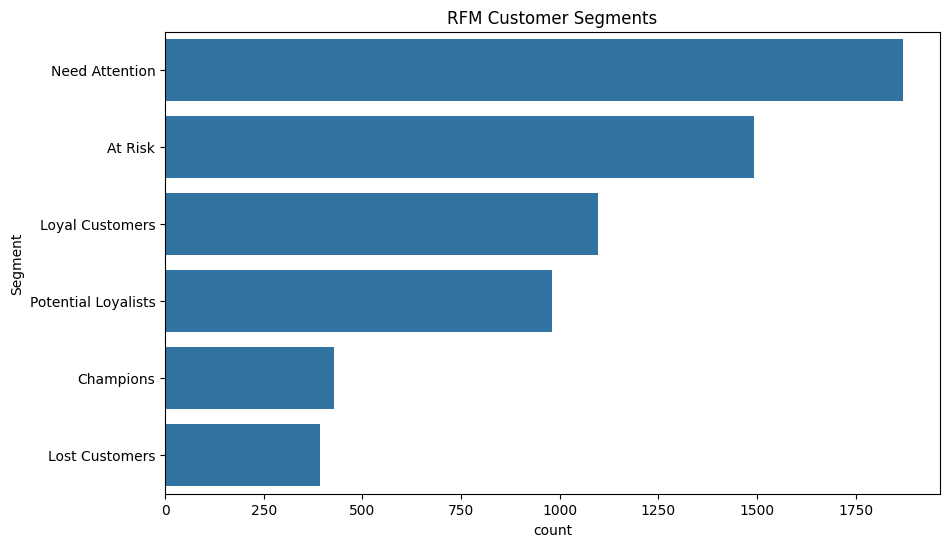

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    y='Segment',
    order=rfm['Segment']
    .value_counts()
    .index
)

plt.title('RFM Customer Segments')

plt.show()

**Revenue Contribution by Segment**

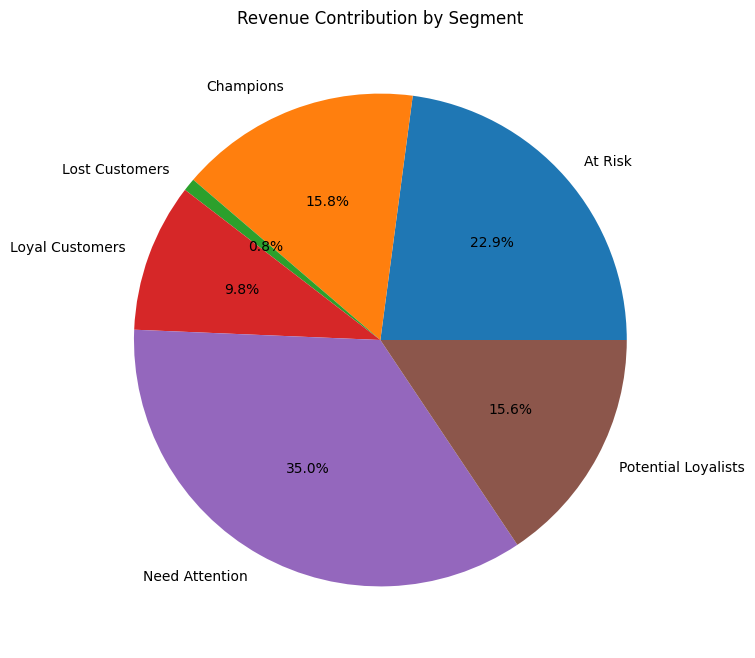

In [ ]:
segment_revenue = (
    rfm.groupby('Segment')
    ['Monetary']
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct='%1.1f%%'
)

plt.title(
    'Revenue Contribution by Segment'
)

plt.show()

**RFM Heatmap**

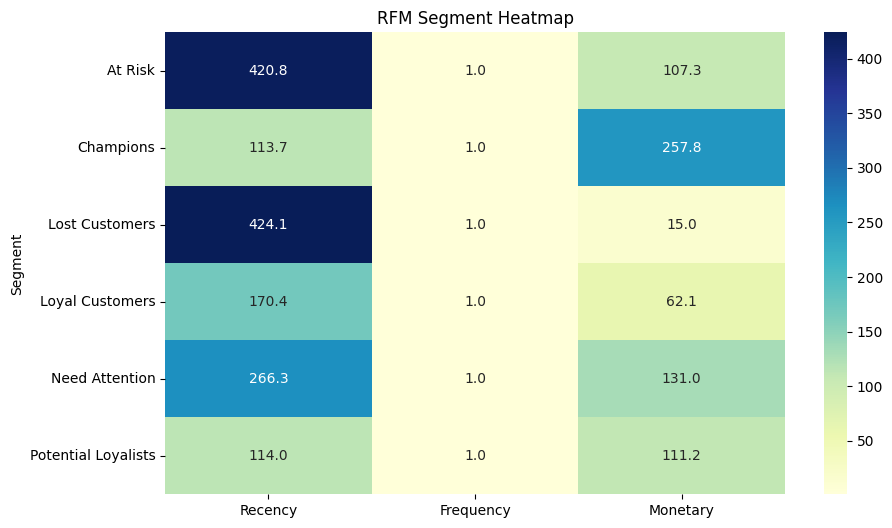

In [ ]:
rfm_heatmap = (
    rfm.groupby('Segment')
    [['Recency',
      'Frequency',
      'Monetary']]
    .mean()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    rfm_heatmap,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title(
    'RFM Segment Heatmap'
)

plt.show()

In [ ]:
segment_table = (
    rfm.groupby('Segment')
    .agg(
        Customer_Count=('CustomerID', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_table

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At Risk,1492,420.798257,1.002681,107.259149
1,Champions,429,113.650350,1.011655,257.800490
2,Lost Customers,393,424.106870,1.000000,14.968473
3,Loyal Customers,1098,170.438069,1.002732,62.128898
4,Need Attention,1870,266.327273,1.000000,130.957144
5,Potential Loyalists,981,113.960245,1.000000,111.249562


In [ ]:
champions = rfm[rfm['Segment'] == 'Champions']
loyal = rfm[rfm['Segment'] == 'Loyal Customers']
potential = rfm[rfm['Segment'] == 'Potential Loyalists']
need_attention = rfm[rfm['Segment'] == 'Need Attention']
at_risk = rfm[rfm['Segment'] == 'At Risk']
lost = rfm[rfm['Segment'] == 'Lost Customers']

In [ ]:
customer_segments = rfm[[
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary',
    'R_Score',
    'F_Score',
    'M_Score',
    'RFM_Score',
    'Segment'
]]

customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,00082cbe03e478190aadbea78542e933,305,1,79.00,2,1,3,213,Need Attention
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90,1,1,3,113,Need Attention
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99,4,1,5,415,Need Attention
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00,4,1,1,411,Need Attention
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00,5,1,2,512,Need Attention


In [ ]:
customer_segments = rfm[[
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary',
    'R_Score',
    'F_Score',
    'M_Score',
    'RFM_Score',
    'Segment'
]]

In [ ]:
print("Total Customers:", customer_segments.shape[0])

Total Customers: 6263


In [ ]:
print(df['customer_unique_id'].nunique())

6263


In [ ]:
segment_count = (
    customer_segments['Segment']
    .value_counts()
    .reset_index()
)

segment_count.columns = [
    'Segment',
    'Customer_Count'
]

segment_count

,Segment,Customer_Count
0,Need Attention,1870
1,At Risk,1492
2,Loyal Customers,1098
3,Potential Loyalists,981
4,Champions,429
5,Lost Customers,393


**view all need campions**

In [ ]:
champions = customer_segments[
    customer_segments['Segment']
    == 'Champions'
]

champions

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1718,47c89a36acb8a73127ec91d0542289b5,138,2,124.80,4,5,4,454,Champions
2908,7a380cb5434e6b6b5b37d45bb99dbe8a,101,2,412.79,5,5,5,555,Champions
3772,9bef45d7ac9f669b72c4360f2e4bc4c1,185,1,109.90,4,4,4,444,Champions
3775,9c215284b65ecf4f6c88edaa22cf1eb0,197,1,193.00,4,4,5,445,Champions
3782,9c69d28b1246f9a2d39c641bb4074544,96,1,105.00,5,4,4,544,Champions
...,...,...,...,...,...,...,...,...,...
6231,ff2521c4012e1a212bbd12c9ed5acc48,49,1,199.90,5,5,5,555,Champions
6238,ff4cee3f89dc5c041bd7fac60e9ec8a6,151,1,152.50,4,5,5,455,Champions
6242,ff60aefe219c1960b74d47d0fc553fc1,44,1,96.80,5,5,4,554,Champions
6251,ff96fbbcff0db5c4442796b8ab8b474d,96,1,115.00,5,5,4,554,Champions


**view all loyal customers**

In [ ]:
loyal_customers = customer_segments[
    customer_segments['Segment']
    == 'Loyal Customers'
]

loyal_customers

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
3016,7e30d2336a1f1182766cf6fb863d5554,128,2,0.00,4,5,1,451,Loyal Customers
3393,8d50f5eadf50201ccdcedfb9e2ac8455,44,3,72.98,5,5,3,553,Loyal Customers
3765,9bb0ec72e0fc4088b5eacfeec3dd3bc7,290,1,75.00,3,4,3,343,Loyal Customers
3766,9bde5e93c160f40d85e89f0279a23a29,141,1,39.99,4,4,2,442,Loyal Customers
3767,9be157b99745700816546b2595668259,221,1,0.00,3,4,1,341,Loyal Customers
...,...,...,...,...,...,...,...,...,...
6248,ff7d3ceb693a77937c000250fe346acd,36,1,16.00,5,5,2,552,Loyal Customers
6250,ff8af8323bfc7b0cb9ed2d6e52bd5d05,250,1,169.00,3,5,5,355,Loyal Customers
6253,ffad6a7a0e13be3dfd9de96a81b77c9e,198,1,70.00,4,5,3,453,Loyal Customers
6255,ffca00fb352b5e57db50865d65098b4a,133,1,39.90,4,5,2,452,Loyal Customers


**viwe all potential loyalists customers**

In [ ]:
potential_loyalists = customer_segments[
    customer_segments['Segment']
    == 'Potential Loyalists'
]

potential_loyalists

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1260,35052a34c8cddade15549afde5580e83,79,1,0.00,5,2,1,521,Potential Loyalists
1262,350b4f552289d46cd2a225f9a5f9d869,54,1,459.80,5,2,5,525,Potential Loyalists
1264,351853efbf1da247efad7b002971072d,147,1,59.90,4,2,3,423,Potential Loyalists
1265,352fd235c6e516d78f7481b9dae3eead,72,1,51.90,5,2,3,523,Potential Loyalists
1275,35aabace9e8c8f00fad6099760de33e0,174,1,55.99,4,2,3,423,Potential Loyalists
...,...,...,...,...,...,...,...,...,...
3753,9b390e923bbf7e3edc2bcb93d8707355,175,1,112.00,4,3,4,434,Potential Loyalists
3754,9b4496ef27f4b987ed84d49a0386c28b,167,1,99.00,4,3,4,434,Potential Loyalists
3755,9b475216704f39cb18ce448648b995e1,42,1,92.90,5,3,4,534,Potential Loyalists
3758,9b74eb2e52bbbb88985c2fb43e02beae,34,1,102.88,5,3,4,534,Potential Loyalists


**view all need atention customers**

In [ ]:
need_attention = customer_segments[
    customer_segments['Segment']
    == 'Need Attention'
]

need_attention

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,00082cbe03e478190aadbea78542e933,305,1,79.00,2,1,3,213,Need Attention
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90,1,1,3,113,Need Attention
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99,4,1,5,415,Need Attention
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00,4,1,1,411,Need Attention
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00,5,1,2,512,Need Attention
...,...,...,...,...,...,...,...,...,...
3746,9ac15e6f0d402baa3170705de3d4590f,281,1,27.99,3,3,2,332,Need Attention
3756,9b4f9870718fc9f864d7d5494d91f477,286,1,0.00,3,3,1,331,Need Attention
3760,9b7c8e3942cbe4bbd22debbb13c2199b,282,1,50.90,3,3,3,333,Need Attention
3762,9b953c95d48d666d4a7da3aec936f1ab,241,1,293.50,3,3,5,335,Need Attention


**View all at risk customers**

In [ ]:
at_risk = customer_segments[
    customer_segments['Segment']
    == 'At Risk'
]

at_risk

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
92,041caba6a63ace5818387698ea85cdb2,308,2,58.99,2,5,3,253,At Risk
452,12f5d6e1cbf93dafd9dcc19095df0b3d,623,2,20.80,1,5,2,152,At Risk
2133,58aa424ba24df5dc745e1a3941abc5a3,616,2,69.90,1,5,3,153,At Risk
2513,6858ce30f88a81273fb705a2fcc52aa7,338,1,249.90,2,3,5,235,At Risk
2515,6862e7a7283767e68fb14c52a110f6d1,303,1,38.00,2,3,2,232,At Risk
...,...,...,...,...,...,...,...,...,...
6257,ffe780a8995715d9560ca10f3351710f,407,1,0.00,2,5,1,251,At Risk
6259,ffe9be10b9a58c5464d833e8b1b2c632,297,1,140.00,2,5,4,254,At Risk
6260,ffef0ffa736c7b3d9af741611089729b,479,1,109.90,1,5,4,154,At Risk
6261,fff699c184bcc967d62fa2c6171765f7,384,1,39.90,2,5,2,252,At Risk


**View All Lost Customers**

In [ ]:
lost_customers = customer_segments[
    customer_segments['Segment']
    == 'Lost Customers'
]

lost_customers

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
5,0037eb1ff742ee2e71ba887f65f3c6f3,435,1,0.00,1,1,1,111,Lost Customers
18,00d03b5e33f8987549c5590313a4ef21,461,1,19.99,1,1,2,112,Lost Customers
25,00f0b70fdcb8a6e1671b52a2472bd41f,716,1,0.00,1,1,1,111,Lost Customers
27,011509f63f565e822767bfb89c3cf9b7,499,1,26.69,1,1,2,112,Lost Customers
32,013f4353d26bb05dc6652f1269458d8d,301,1,0.00,2,1,1,211,Lost Customers
...,...,...,...,...,...,...,...,...,...
2480,674b8bca7cdaac71777cd026ebb31c43,531,1,39.90,1,2,2,122,Lost Customers
2483,6753845f8bc48b027c01c90f13d41f3b,410,1,18.99,1,2,2,122,Lost Customers
2485,67697f1ef23332d4be711eba56d04b4c,472,1,0.00,1,2,1,121,Lost Customers
2505,68086630405120fd049f0d41aaee9a68,567,1,38.90,1,2,2,122,Lost Customers


In [ ]:
customer_segments.to_excel(
    'RFM_Customer_Segmentation.xlsx',
    index=False
)